Manual synthetic data generation for a single event & site to find the bug in the code

In [1]:
from pathlib import Path

import einops
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import spatial_hazard as sh
import sim_ranking as sr
import sha_calc as sha
from mera.mera_pymer4 import run_mera
import ml_tools as mlt

In [2]:
gm_params_ffp = Path("/Users/claudy/dev/work/data/sim_ranking/emp_gm_params/nzgmdb/emp_gm_params.csv")
gm_params = pd.read_csv(gm_params_ffp, index_col=0)

In [3]:
site_ffp = Path("/Users/claudy/dev/work/data/gm_datasets/nz_gmdb/v3.0/Tables/site_table.csv")
site_df = pd.read_csv(site_ffp, index_col="sta")

In [4]:
event = "2016p118944"
gm_params = gm_params.loc[gm_params.event == event]
sites = gm_params.site.values.astype(str)

ims = sr.constants.PSA_KEYS 

In [5]:
# Compute the distance matrix
dist_matrix = sh.im_dist.calculate_distance_matrix(sites, site_df)

# Spatial-Correlation Only

In [57]:
# Generate the correlation matrix
n_rels = 1000
im_results = {}
between_results = {}
within_results = {}
R_matrices = {}
for cur_im in ims:
	cur_gm_params = gm_params[[f"{cur_im}_mean", f"{cur_im}_std_Inter", f"{cur_im}_std_Intra"]].rename(columns={f"{cur_im}_mean": "mu", f"{cur_im}_std_Inter": "between_event_sigma", f"{cur_im}_std_Intra": "within_event_sigma"})
	R_matrices[cur_im] = R = sh.im_dist.get_corr_matrix(sites, dist_matrix, cur_im)
	cur_ims, cur_between, cur_within = sh.im_dist.gen_spatial_im_rels(n_rels, R, cur_gm_params)
	
	im_results[cur_im] = pd.DataFrame(data=cur_ims, columns=sites)
	between_results[cur_im] = pd.DataFrame(data=cur_between, columns=sites)
	within_results[cur_im] = pd.DataFrame(data=cur_within, columns=sites)
	

In [58]:
cur_site = "ADCS"

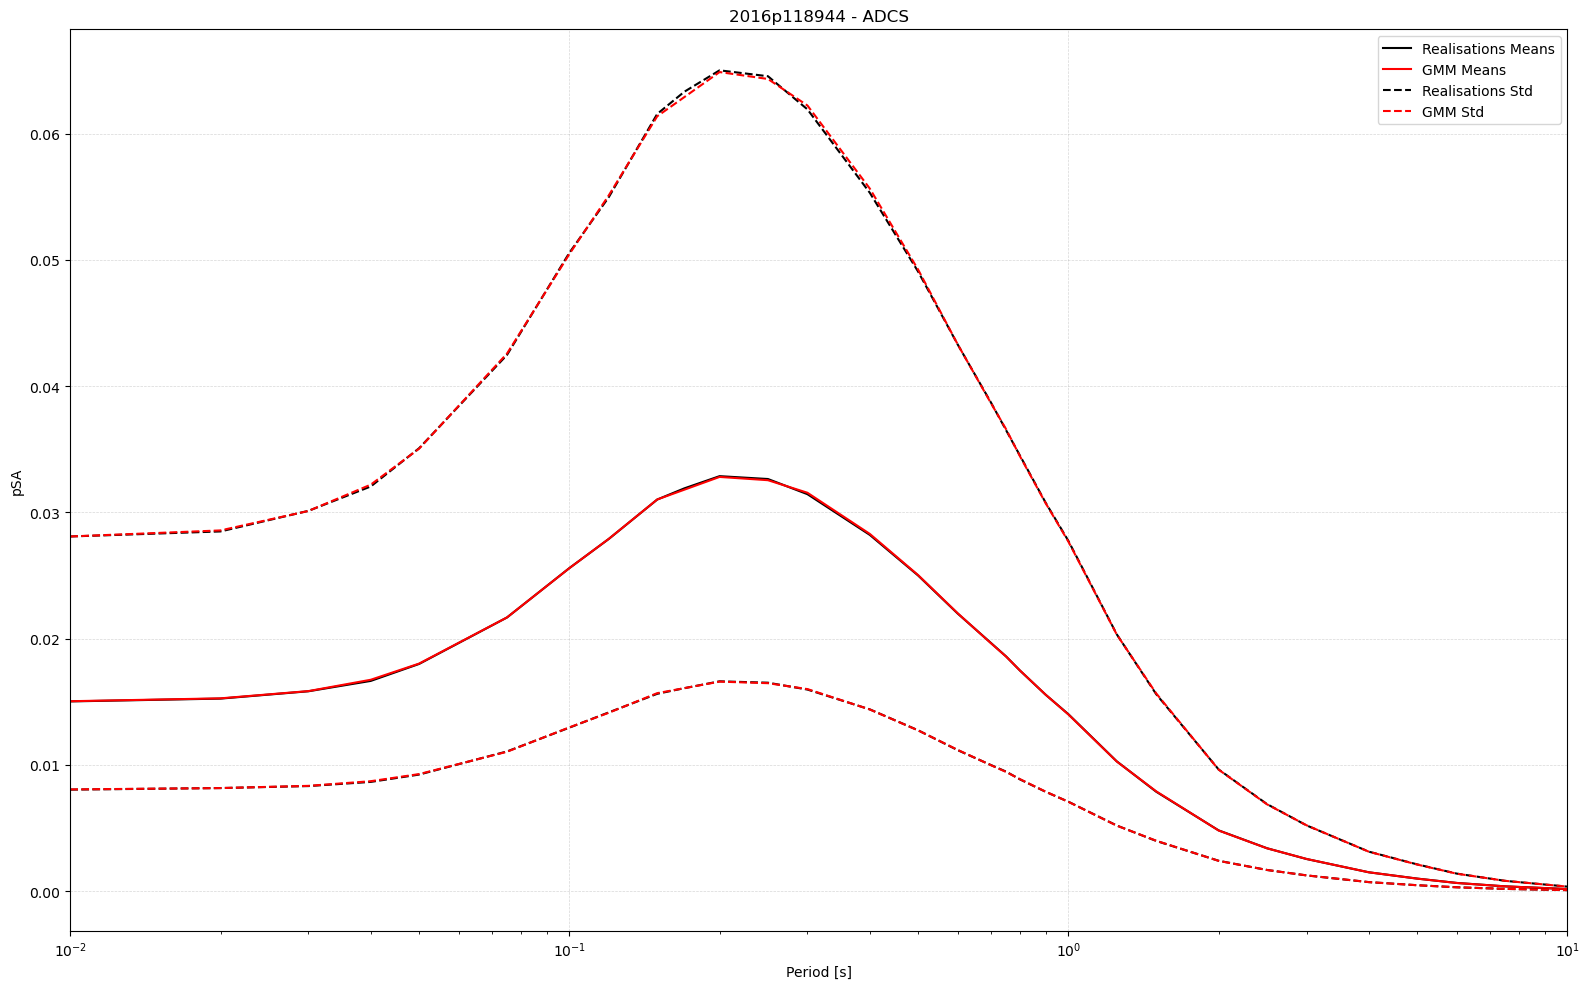

In [59]:
rel_means, rel_stds = [], []
gmm_means, gmm_stds = [], []
for cur_im in sr.constants.PSA_KEYS:
	rel_means.append(np.mean(im_results[cur_im][cur_site]))
	rel_stds.append(np.std(im_results[cur_im][cur_site]))
	gmm_means.append(gm_params.loc[f"{event}_{cur_site}", f"{cur_im}_mean"])
	gmm_stds.append(gm_params.loc[f"{event}_{cur_site}", f"{cur_im}_std_Total"])
	
rel_means = np.array(rel_means)
rel_stds = np.array(rel_stds)
gmm_means = np.array(gmm_means)
gmm_stds = np.array(gmm_stds)

fig = plt.figure(figsize=(16, 10))

plt.semilogx(sr.constants.PERIODS, np.exp(rel_means), label="Realisations Means", c="k");
plt.semilogx(sr.constants.PERIODS, np.exp(gmm_means), label="GMM Means", c="r");

plt.semilogx(sr.constants.PERIODS, np.exp(rel_means + rel_stds), label="Realisations Std", c="k", linestyle="--");
plt.semilogx(sr.constants.PERIODS, np.exp(rel_means - rel_stds), c="k", linestyle="--");

plt.semilogx(sr.constants.PERIODS, np.exp(gmm_means + gmm_stds), label="GMM Std", c="r", linestyle="--");
plt.semilogx(sr.constants.PERIODS, np.exp(gmm_means - gmm_stds), c="r", linestyle="--");

plt.title(f"{event} - {cur_site}");
plt.xlabel(f"Period [s]")
plt.ylabel(f"pSA")
plt.xlim(0.01, 10)
plt.grid(linewidth=0.5, alpha=0.5, linestyle="--")
plt.legend()
plt.tight_layout()

In [60]:
# Compute the within-event correlation matrix
est_within_corr = {cur_im: within_results[cur_im].corr() for cur_im in ims}

In [61]:
def plot_corr(corr_df, dist_matrix, mask, title = None, log: bool = False):
	fig, ax = plt.subplots(figsize=(16, 10))
	ax.scatter(
	    dist_matrix.values[mask],
	    corr_df.values[mask],
	    s=1.5,
	    c="b",
	)
	
	dist = np.linspace(0.001, 300, 1000)
	loth_baker_vals = sha.loth_baker_corr_model.get_correlations(cur_im, cur_im, dist)
	if log:
		ax.semilogx(dist, loth_baker_vals, c="k", linewidth=1.0)
		ax.set_xlim(0.01, 300)
	else:
		ax.plot(dist, loth_baker_vals, c="k", linewidth=1.0)
		ax.set_xlim(0.0, 300)
	
	if title is not None:
		ax.set_title(title)
	
	ax.set_xlabel(f"Distance (km)")
	ax.set_ylabel(f"Site-Correlation")
	ax.set_ylim(-1.0, 1.0)
	ax.set_xlim(0.0, 100)
	ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")
	# ax.legend()
	fig.tight_layout()

In [62]:
cur_im = "pSA_10.0"
cur_corr_df = est_within_corr[cur_im]
assert cur_corr_df.index.equals(dist_matrix.index)

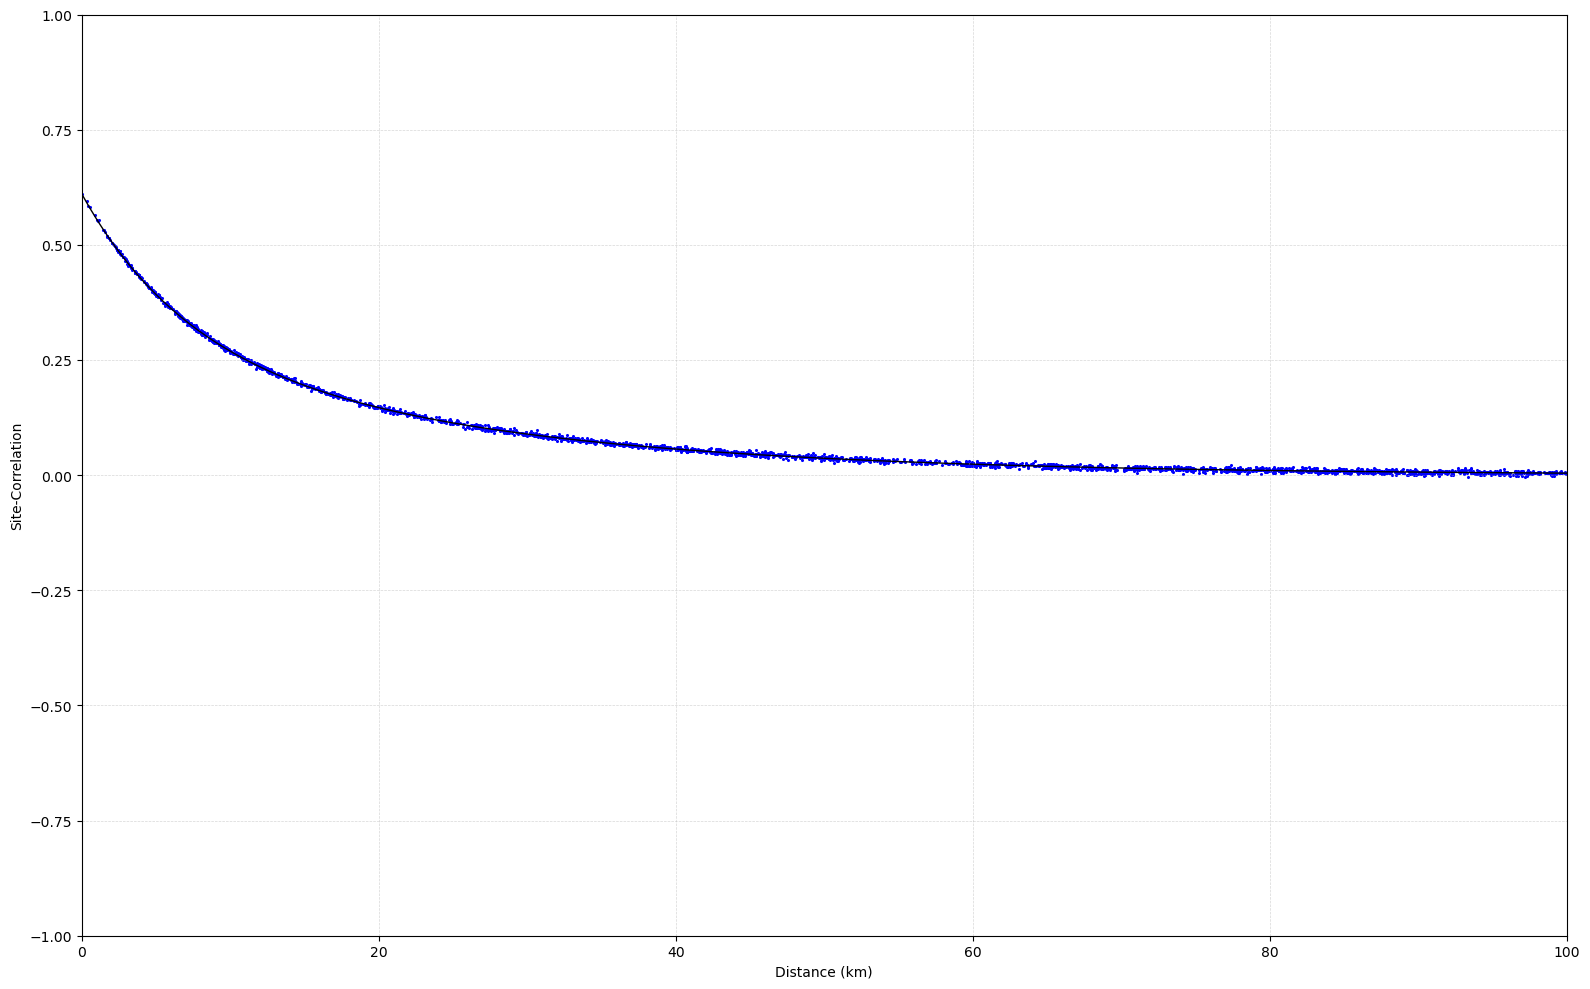

In [63]:
mask = np.tril(dist_matrix.values).astype(bool) & ~cur_corr_df.isna().values
plot_corr(cur_corr_df, dist_matrix, mask, log=False)

In [56]:
## IM correlations
# cur_im_corrs = im_results[cur_im].corr()
# assert cur_im_corrs.index.equals(dist_matrix.index)
# mask = np.tril(dist_matrix.values).astype(bool) & ~cur_im_corrs.isna().values
# plot_corr(cur_im_corrs, dist_matrix, mask, log=False)

## Estimate GM Params using Mera

In [64]:
# Estimate GM Parameters
cur_im_df = im_results[cur_im]
cur_site_mean_df = cur_im_df.mean(axis=0)
cur_residuals = cur_im_df - cur_site_mean_df

cur_res_df = pd.DataFrame(data=einops.rearrange(cur_residuals.values, "rel site -> (site rel)", site=sites.size), columns=[cur_im])
cur_res_df["site"] = np.repeat(sites, n_rels)
# cur_res_df["rel"] =  mlt.array_utils.numpy_str_join("", "REL", np.tile(np.arange(n_rels), sites.size).astype(str))
cur_res_df["rel"] = np.tile(np.arange(n_rels), sites.size)
cur_res_df.index = mlt.array_utils.numpy_str_join("_", cur_res_df["site"].values.astype(str), cur_res_df["rel"].values.astype(str))

In [65]:
event_res_df, within_res, bias_std_df = run_mera(cur_res_df, [cur_im], "rel", "site", compute_site_term=False)
event_res_df.index = event_res_df.index.values.astype(int)
event_res_df = event_res_df.sort_index()

assert np.all(within_res.index == cur_res_df.index)
within_res["site"] = cur_res_df["site"]
within_res["rel"] = cur_res_df["rel"]

Processing IM pSA_10.0, 1/1


In [66]:
cur_mera_est_corr = within_res.pivot(index="rel", columns="site", values=cur_im).corr()

In [67]:
between_results[cur_im]

,ADCS,AKCZ,AKSS,AMBC,AMCZ,APPS,ARCZ,ASHS,BBCX,BSWZ,...,WAKC,WBCS,WCSS,WDFS,WHAS,WHFS,WIGC,WSFC,WVAS,WVZ
0,-0.510941,-0.510941,-0.510941,-0.510941,-0.510941,-0.510941,-0.510941,-0.510941,-0.510941,-0.510941,...,-0.510941,-0.510941,-0.510941,-0.510941,-0.510941,-0.510941,-0.510941,-0.510941,-0.510941,-0.510941
1,0.703529,0.703529,0.703529,0.703529,0.703529,0.703529,0.703529,0.703529,0.703529,0.703529,...,0.703529,0.703529,0.703529,0.703529,0.703529,0.703529,0.703529,0.703529,0.703529,0.703529
2,-0.388648,-0.388648,-0.388648,-0.388648,-0.388648,-0.388648,-0.388648,-0.388648,-0.388648,-0.388648,...,-0.388648,-0.388648,-0.388648,-0.388648,-0.388648,-0.388648,-0.388648,-0.388648,-0.388648,-0.388648
3,-0.294928,-0.294928,-0.294928,-0.294928,-0.294928,-0.294928,-0.294928,-0.294928,-0.294928,-0.294928,...,-0.294928,-0.294928,-0.294928,-0.294928,-0.294928,-0.294928,-0.294928,-0.294928,-0.294928,-0.294928
4,-0.252167,-0.252167,-0.252167,-0.252167,-0.252167,-0.252167,-0.252167,-0.252167,-0.252167,-0.252167,...,-0.252167,-0.252167,-0.252167,-0.252167,-0.252167,-0.252167,-0.252167,-0.252167,-0.252167,-0.252167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,-0.177122,-0.177122,-0.177122,-0.177122,-0.177122,-0.177122,-0.177122,-0.177122,-0.177122,-0.177122,...,-0.177122,-0.177122,-0.177122,-0.177122,-0.177122,-0.177122,-0.177122,-0.177122,-0.177122,-0.177122
99996,-0.355697,-0.355697,-0.355697,-0.355697,-0.355697,-0.355697,-0.355697,-0.355697,-0.355697,-0.355697,...,-0.355697,-0.355697,-0.355697,-0.355697,-0.355697,-0.355697,-0.355697,-0.355697,-0.355697,-0.355697
99997,-0.063240,-0.063240,-0.063240,-0.063240,-0.063240,-0.063240,-0.063240,-0.063240,-0.063240,-0.063240,...,-0.063240,-0.063240,-0.063240,-0.063240,-0.063240,-0.063240,-0.063240,-0.063240,-0.063240,-0.063240
99998,0.190165,0.190165,0.190165,0.190165,0.190165,0.190165,0.190165,0.190165,0.190165,0.190165,...,0.190165,0.190165,0.190165,0.190165,0.190165,0.190165,0.190165,0.190165,0.190165,0.190165


In [68]:
event_res_df

,pSA_10.0
0,-0.545411
1,0.578478
2,-0.331067
3,-0.607210
4,-0.129494
...,...
99995,-0.262213
99996,-0.181271
99997,0.005195
99998,0.266652


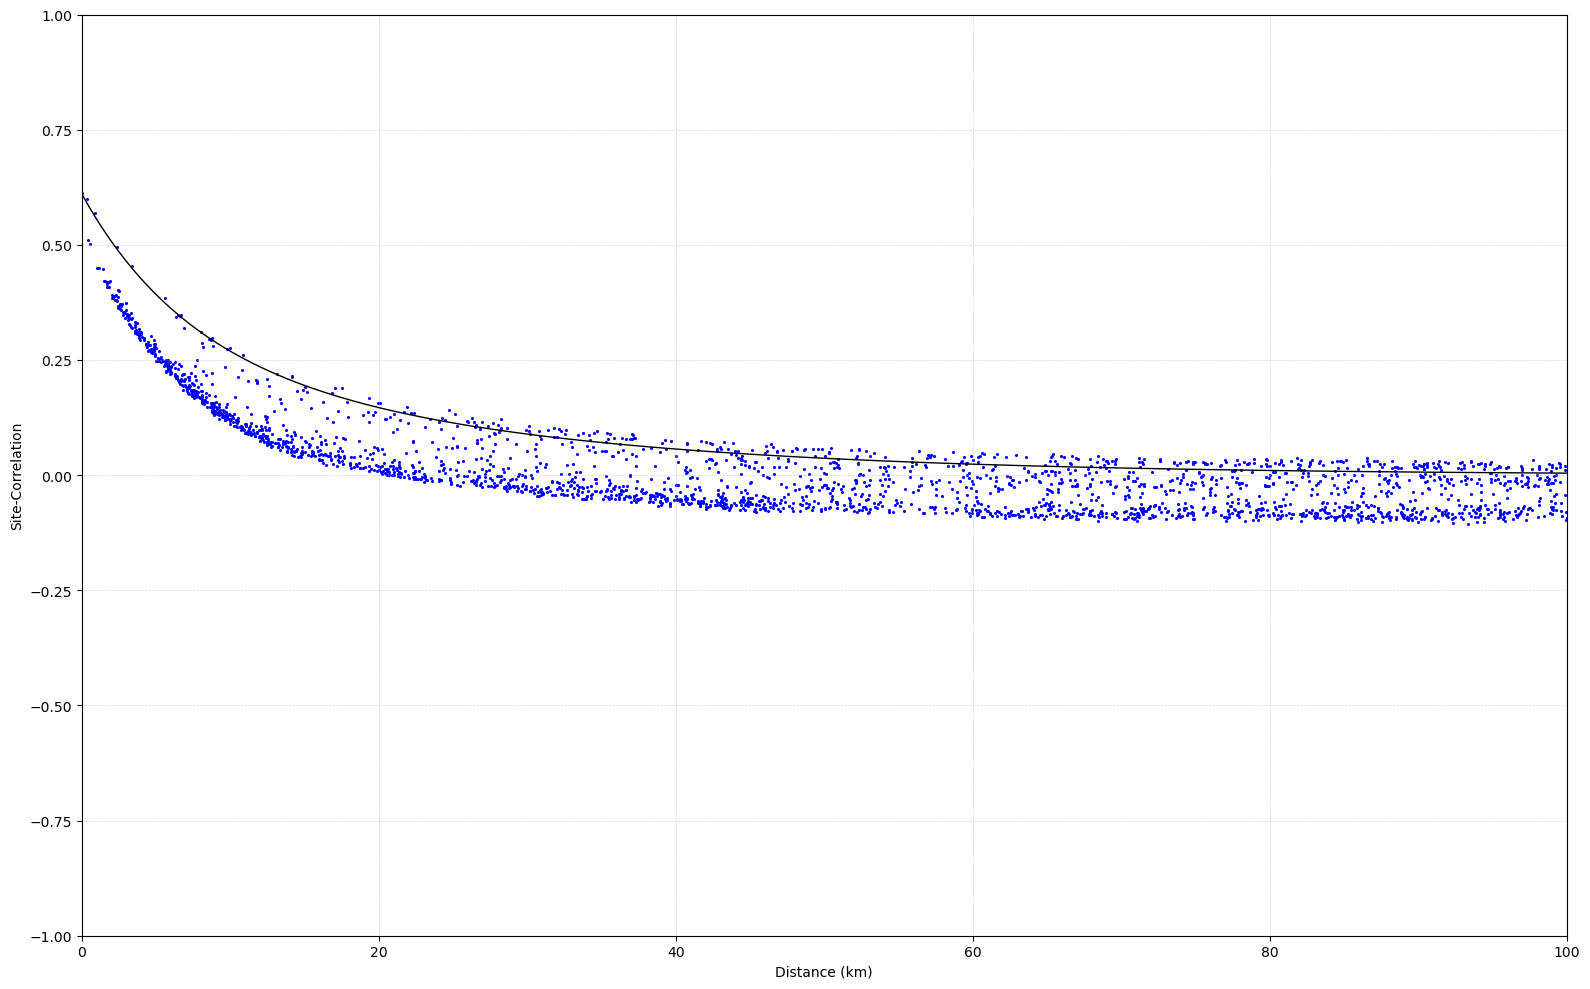

In [69]:
assert cur_mera_est_corr.index.equals(dist_matrix.index)
mask = np.tril(dist_matrix.values).astype(bool) & ~cur_mera_est_corr.isna().values
plot_corr(cur_mera_est_corr, dist_matrix, mask, log=False)

In [70]:
within_res

,pSA_10.0,site,rel
ADCS_0,0.296094,ADCS,0
ADCS_1,0.821048,ADCS,1
ADCS_2,-0.220859,ADCS,2
ADCS_3,0.159952,ADCS,3
ADCS_4,0.569839,ADCS,4
...,...,...,...
WVZ_99995,-0.503358,WVZ,99995
WVZ_99996,0.058148,WVZ,99996
WVZ_99997,-0.305443,WVZ,99997
WVZ_99998,0.227395,WVZ,99998


In [71]:
within_results[cur_im]

,ADCS,AKCZ,AKSS,AMBC,AMCZ,APPS,ARCZ,ASHS,BBCX,BSWZ,...,WAKC,WBCS,WCSS,WDFS,WHAS,WHFS,WIGC,WSFC,WVAS,WVZ
0,0.261511,-0.452703,-0.489998,-1.400211,-0.174482,0.407483,0.823597,-0.487918,-0.072504,-0.329838,...,-0.062576,0.573223,0.698448,0.423712,0.374288,0.160619,0.403276,0.449838,0.617053,-0.031695
1,0.695884,0.252865,0.717162,-1.596580,-0.572945,0.094637,-0.188777,0.952257,0.252685,-0.917951,...,-1.225195,-1.014853,-0.011362,0.757110,0.081166,0.137685,0.116909,-0.138522,0.412200,-0.468936
2,-0.163391,-0.272366,-1.476706,0.574122,0.473990,1.373486,0.280140,-0.629009,0.051493,0.719894,...,-0.427276,-0.748020,-0.184626,0.728402,-0.506654,1.217931,-0.593100,-0.221799,-0.442308,-0.597091
3,-0.152443,-0.426474,-0.574722,-0.522370,-0.662193,0.029059,-0.721822,-0.604031,-0.076660,-0.399535,...,-0.189299,-0.806529,0.568062,-0.397683,-0.823898,-1.158777,-0.457579,0.162509,-0.239194,-0.475377
4,0.692397,-0.910020,-0.860147,0.184634,-0.852894,0.071676,0.108061,0.651489,0.739317,0.366139,...,-0.575556,1.194480,0.485870,0.381672,0.363639,-0.159894,0.239540,0.110539,-0.107950,0.864557
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,-0.016527,-0.912717,-0.625507,-0.390304,-1.012450,-0.258042,0.128441,0.516914,-0.132360,0.257158,...,-0.609718,-0.080466,0.174677,0.661483,0.402530,0.181862,0.324973,-0.670953,-0.120357,-0.589897
99996,-0.071107,0.334774,0.095152,0.495298,0.267821,-0.161539,-0.833650,0.351355,-0.012974,-0.410397,...,0.479231,-0.698710,-0.027247,-0.210253,0.742189,-0.143641,-0.232474,-0.071409,-0.118151,0.231125
99997,0.943667,-0.143727,0.744836,0.752373,1.130793,0.251739,-0.411746,0.049119,-0.037261,-0.137857,...,0.035180,0.144841,1.010949,0.615760,0.065631,0.151577,0.280303,0.360811,-0.652343,-0.238455
99998,0.755704,-0.255984,0.213028,0.374835,0.955314,-0.612441,-1.337191,0.300809,0.160544,-0.017772,...,-0.362811,0.780478,0.452900,-0.638451,0.046841,-0.481866,-0.149168,0.087317,1.049102,0.302434


In [72]:
gm_params.loc[:, [f"{cur_im}_mean", f"{cur_im}_std_Inter", f"{cur_im}_std_Intra", f"{cur_im}_std_Total"]]

,pSA_10.0_mean,pSA_10.0_std_Inter,pSA_10.0_std_Intra,pSA_10.0_std_Total
id,,,,
2016p118944_ADCS,-8.751869,0.5542,0.565032,0.791454
2016p118944_AKCZ,-8.587741,0.5542,0.565032,0.791454
2016p118944_AKSS,-7.837449,0.5542,0.565032,0.791454
2016p118944_AMBC,-7.345755,0.5542,0.565032,0.791454
2016p118944_AMCZ,-8.688335,0.5542,0.565032,0.791454
...,...,...,...,...
2016p118944_WHFS,-9.437014,0.5542,0.565032,0.791454
2016p118944_WIGC,-9.218195,0.5542,0.565032,0.791454
2016p118944_WSFC,-8.944921,0.5542,0.565032,0.791454


# Cross Correlation

In [ ]:
gm_params = gm_params.set_index("site")

In [34]:
im_values, between_event_residual, within_event_residual = sh.im_dist.gen_im_rels(gm_params, dist_matrix, ims, 1000)

In [35]:
# Compute the within-event correlation matrix
est_within_corr = {cur_im: pd.DataFrame(data=np.corrcoef(within_event_residual[:, ix, :]), index=sites, columns=sites) for ix, cur_im in enumerate(ims)}

In [36]:
cur_im = "pSA_10.0"
cur_corr_df = est_within_corr[cur_im]
assert cur_corr_df.index.equals(dist_matrix.index)

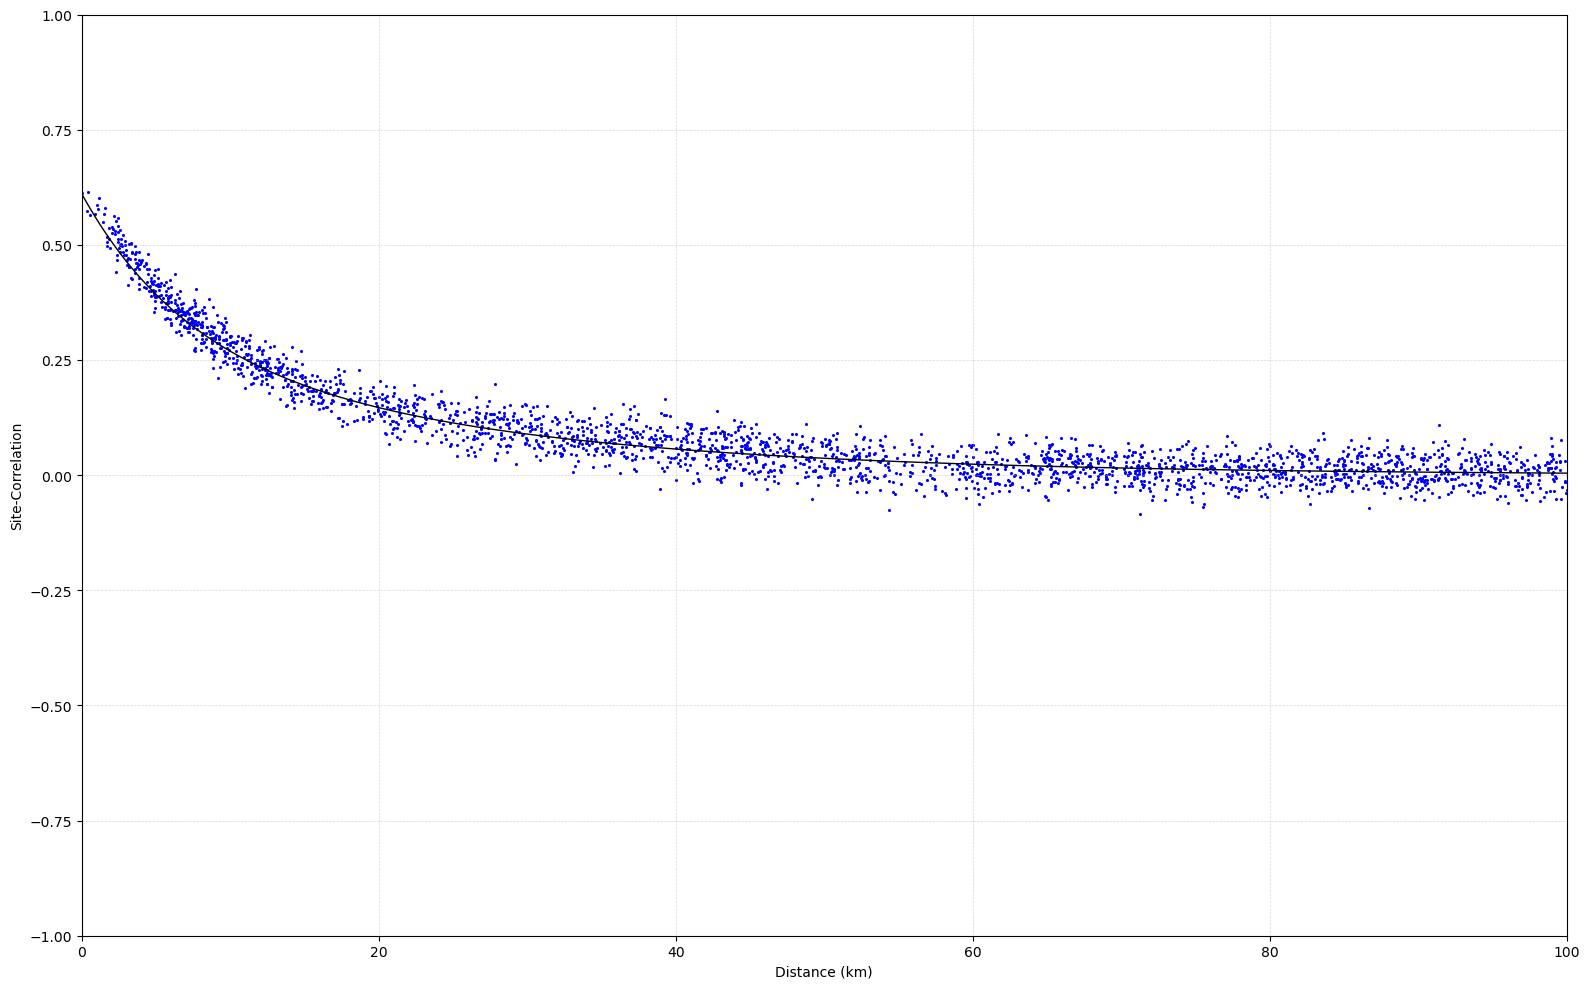

In [38]:
mask = np.tril(dist_matrix.values).astype(bool) & ~cur_corr_df.isna().values
plot_corr(cur_corr_df, dist_matrix, mask, log=False)